## Setup & Load Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import warnings
warnings.filterwarnings('ignore') 

In [6]:
df = pd.read_csv(r"D:\DATASETS\Dataset.csv")

## 1️⃣	Data Cleaning & Preprocessing
    o	Handle missing or inconsistent data.
    o	Convert date/time columns to appropriate formats.
    o	Standardize categorical variables.

In [6]:
# remove hidden spaces in column names
df.columns = df.columns.str.strip()  

#To check shape of data
print("Shape: ",df.shape)

print("\nType of data: ",df.dtypes)

#Description
print("\nDiscription:\n ",df.describe(include = "all"))

#Unique_values
print("\nUnique values: ",df.nunique())

#all null values
print("\nNull Values: ",df.isnull().sum())

#All columns name
print(df.columns)

#TO check duplicates
print(df.duplicated().sum())

Shape:  (150000, 21)

Type of data:  Date                                  object
Time                                  object
Booking ID                            object
Booking Status                        object
Customer ID                           object
Vehicle Type                          object
Pickup Location                       object
Drop Location                         object
Avg VTAT                             float64
Avg CTAT                             float64
Cancelled Rides by Customer          float64
Reason for cancelling by Customer     object
Cancelled Rides by Driver            float64
Driver Cancellation Reason            object
Incomplete Rides                     float64
Incomplete Rides Reason               object
Booking Value                        float64
Ride Distance                        float64
Driver Ratings                       float64
Customer Rating                      float64
Payment Method                        object
dtype: object

Dis

In [7]:
# 🔧 FIX: keep Time as datetime first (for Hour extraction later)
df['Date'] = pd.to_datetime(df['Date'], errors = 'coerce')
df['Time'] = pd.to_datetime(df['Time'], errors = 'coerce')  

# Handle missing values
df = df.dropna(subset=['Booking Status'])

#Fill numeric column with median
num_col = ['Avg VTAT','Avg CTAT','Cancelled Rides by Customer',
           'Cancelled Rides by Driver','Incomplete Rides',
           'Booking Value','Ride Distance','Driver Ratings','Customer Rating']
for col in num_col:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col].fillna(df[col].median(), inplace=True)

#Fill categorical columns with 'unknown'
cat_col = ['Booking Status','Vehicle Type','Pickup Location','Drop Location',
           'Reason for cancelling by Customer','Driver Cancellation Reason',
           'Incomplete Rides Reason','Payment Method']
for col in cat_col:
    df[col] = df[col].astype(str).str.strip().str.title()
    df[col].fillna('Unknown', inplace = True)

print(df.isnull().sum()) #Should be zero or near-zero 

Date                                 0
Time                                 0
Booking ID                           0
Booking Status                       0
Customer ID                          0
Vehicle Type                         0
Pickup Location                      0
Drop Location                        0
Avg VTAT                             0
Avg CTAT                             0
Cancelled Rides by Customer          0
Reason for cancelling by Customer    0
Cancelled Rides by Driver            0
Driver Cancellation Reason           0
Incomplete Rides                     0
Incomplete Rides Reason              0
Booking Value                        0
Ride Distance                        0
Driver Ratings                       0
Customer Rating                      0
Payment Method                       0
dtype: int64


In [8]:
#Standardize categories
cols_to_standardize = ['Vehicle Type', 'Booking Status', 'Payment Method', 'Pickup Location', 'Drop Location']
df[cols_to_standardize] = df[cols_to_standardize].apply(lambda x: x.str.strip().str.title())

## 2️⃣	Descriptive Analysis

Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
Ebike            10557
Uber Xl           4449
Name: count, dtype: int64


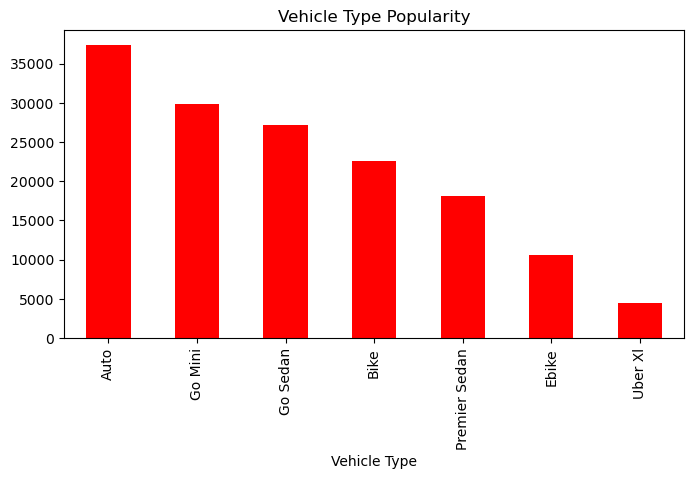

In [10]:
#     o	What are the most and least popular vehicle types?
vehicle_counts = df['Vehicle Type'].value_counts()
print(vehicle_counts)
vehicle_counts.plot(kind='bar', figsize=(8,4), title="Vehicle Type Popularity", color='r')
plt.show()

In [11]:
#     o	What is the average ride distance and booking value?
print("Avg distance: ",round(df['Ride Distance'].mean(),2))
print("Avg booking value: ",round(df['Booking Value'].mean(),2))

Avg distance:  24.34
Avg booking value:  478.12


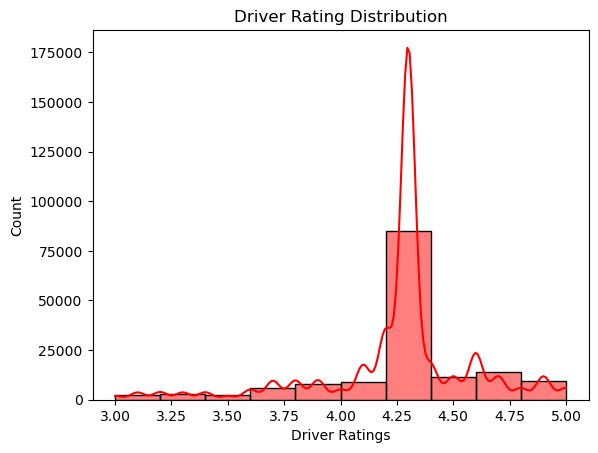

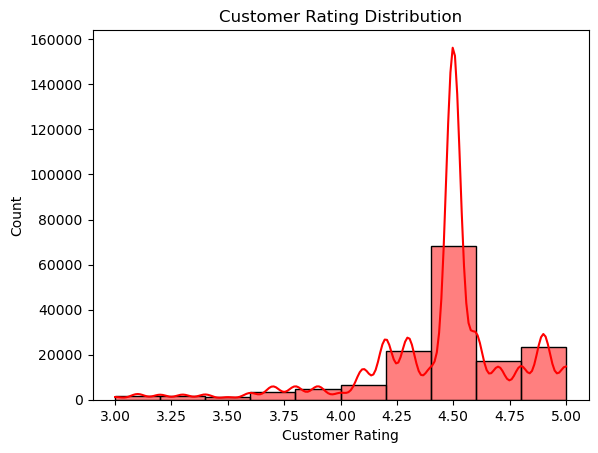

In [12]:
#     o	Distribution of ratings (drivers and customers).
sns.histplot(df['Driver Ratings'], bins=10, kde=True, color='r')
plt.title("Driver Rating Distribution")
plt.show()

sns.histplot(df['Customer Rating'], bins=10, kde=True, color='r')
plt.title("Customer Rating Distribution")
plt.show()


In [13]:
#     o	Most common cancellation reasons by customers and drivers.
print(df['Reason for cancelling by Customer'].value_counts().head(10))
print('\n')
print(df['Driver Cancellation Reason'].value_counts().head(10))

Reason for cancelling by Customer
Nan                                             139500
Wrong Address                                     2362
Change Of Plans                                   2353
Driver Is Not Moving Towards Pickup Location      2335
Driver Asked To Cancel                            2295
Ac Is Not Working                                 1155
Name: count, dtype: int64


Driver Cancellation Reason
Nan                                    123000
Customer Related Issue                   6837
The Customer Was Coughing/Sick           6751
Personal & Car Related Issues            6726
More Than Permitted People In There      6686
Name: count, dtype: int64


## 3️⃣Customer Behavior Insights

In [15]:
df['DayOfWeek'] = df['Date'].dt.day_name()  
df['Hour'] = df['Time'].dt.hour              
df['Time'] = df['Time'].dt.time              

#     o	Who are the frequent cancellers (by customer ID)?
df_cancel = df[df['Booking Status'].str.contains("Cancel", case=False)]
print(df_cancel['Customer ID'].value_counts().head(10))


plt.show()

Customer ID
"CID5290452"    2
"CID6844544"    2
"CID8416905"    2
"CID1617901"    2
"CID7305349"    2
"CID6797938"    2
"CID3333519"    2
"CID2359874"    2
"CID5431712"    2
"CID2922881"    2
Name: count, dtype: int64


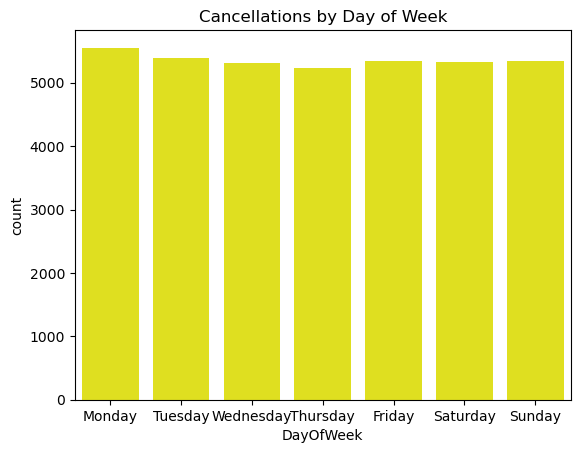

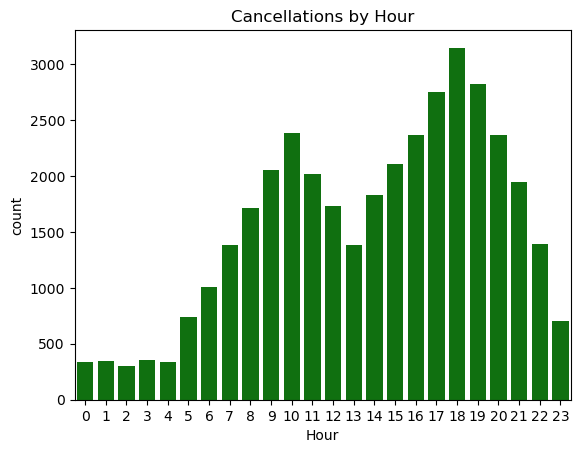

In [16]:
#     o	Is there a pattern in cancellations by time of day or day of week?
sns.countplot(x='DayOfWeek', data=df_cancel, color='yellow',
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Cancellations by Day of Week")
plt.show()

sns.countplot(x='Hour', data=df_cancel,color='green')
plt.title("Cancellations by Hour")
plt.show()

<Axes: >

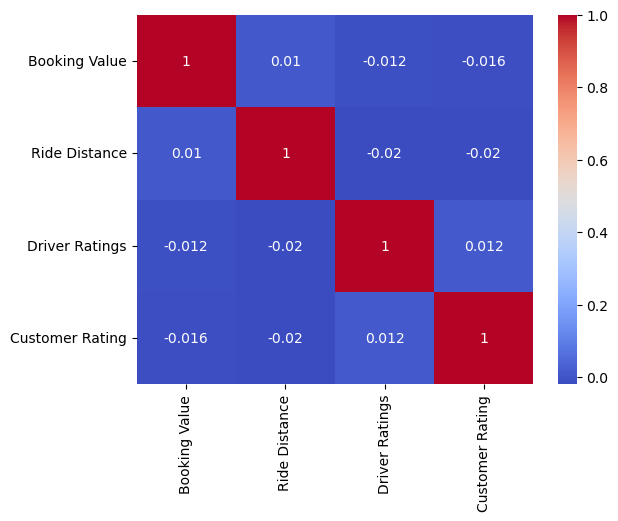

In [17]:
#     o	Correlation between ride value, distance, and customer satisfaction.
cols = ['Booking Value','Ride Distance','Driver Ratings','Customer Rating']
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")

## 4️⃣Driver Performance Evaluation

In [19]:
#     o	Which drivers have the highest/lowest ratings?
print("Highest Driver Rating:", df['Driver Ratings'].max())
print("Lowest Driver Rating:", df['Driver Ratings'].min())
print("Average Driver Rating:", round(df['Driver Ratings'].mean(),2))

Highest Driver Rating: 5.0
Lowest Driver Rating: 3.0
Average Driver Rating: 4.26


In [20]:
#     o	How many rides are being cancelled by drivers and why?
driver_cancels = df[df['Booking Status'].str.contains("cancel", case=False)]
print(driver_cancels['Driver Cancellation Reason'].value_counts())
print("Total driver cancellations:", driver_cancels.shape[0])

Driver Cancellation Reason
Nan                                    10500
Customer Related Issue                  6837
The Customer Was Coughing/Sick          6751
Personal & Car Related Issues           6726
More Than Permitted People In There     6686
Name: count, dtype: int64
Total driver cancellations: 37500


## 5.Operational Metrics

In [22]:
# 5.	Operational Metrics
#     o	Average VTAT and CTAT across vehicle types and locations.
print(df.groupby('Vehicle Type')[['Avg VTAT','Avg CTAT']].mean())



               Avg VTAT   Avg CTAT
Vehicle Type                      
Auto           8.437673  29.032492
Bike           8.486690  29.072416
Ebike          8.465814  29.056579
Go Mini        8.456737  29.045437
Go Sedan       8.394260  28.962127
Premier Sedan  8.428944  29.084733
Uber Xl        8.556237  29.080512


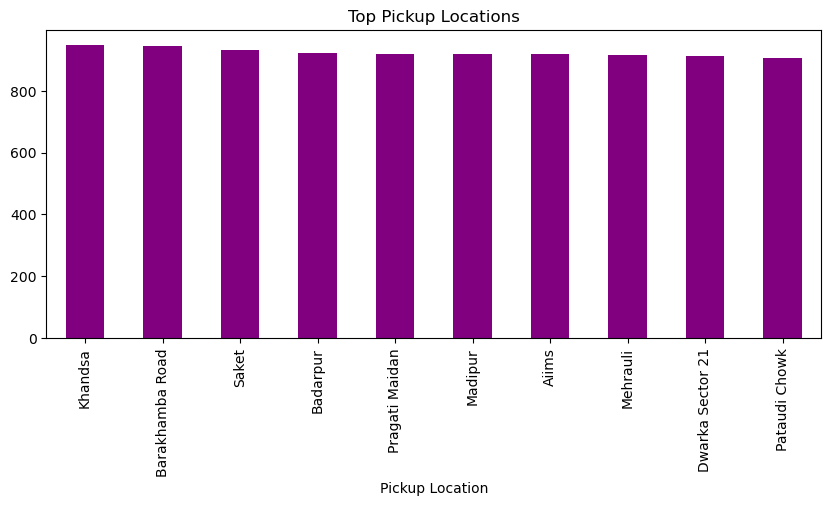

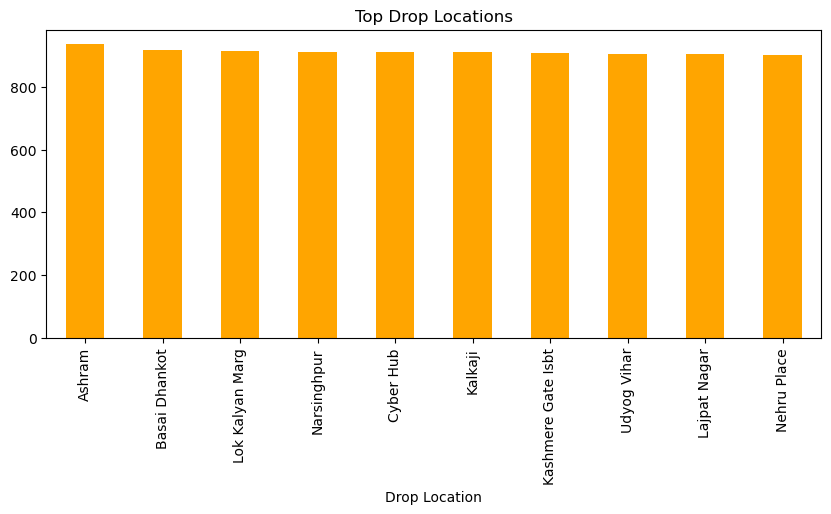

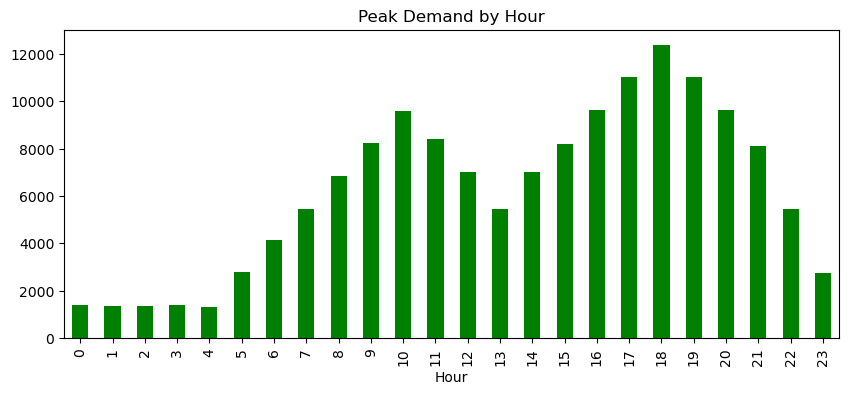

In [23]:
#     o	Identify peak demand locations and time slots.
# **Pickup locations**
pickup_counts = df['Pickup Location'].value_counts().head(10)
pickup_counts.plot(kind='bar', figsize=(10,4), color='purple', title="Top Pickup Locations")
plt.show()

# **Drop locations**
drop_counts = df['Drop Location'].value_counts().head(10)
drop_counts.plot(kind='bar', figsize=(10,4), color='orange', title="Top Drop Locations")
plt.show()

# **Time slots**
df['Hour'].value_counts().sort_index().plot(kind='bar', figsize=(10,4), color='green')
plt.title("Peak Demand by Hour")
plt.show()

## 6️⃣ Save Cleaned Data

In [25]:
df.to_csv("final_Dataset_cleaned.csv", index=False)